# H&M Transaction Data: Product Recommendations 01

In [80]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

import os
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# data processing classes
from src.customer_features import CustomerFeatureEngineer
from src.product_features import ProductFeatureEngineer
from src.recommendation_training import RecommendationTrainingBuilder

## Data loading

In [2]:
data_path = Path("../data")
customers = pd.read_csv(data_path / 'customer_hm_cleaned.csv')
transactions = pd.read_csv(data_path / 'transactions_hm_cleaned.csv')
articles = pd.read_csv(data_path / 'articles_hm_cleaned.csv')

In [3]:
print("Cleaned Rows of Data:")
print(f"Articles: {len(articles):,}")
print(f"Customers: {len(customers):,}")
print(f"Transactions: {len(transactions):,}")

Cleaned Rows of Data:
Articles: 105,542
Customers: 1,048,575
Transactions: 1,040,101


In [4]:
# Sample data for faster execution
TRANSACTIONS_SAMPLE_SIZE = 500000
transactions_sample = transactions.sample(n=TRANSACTIONS_SAMPLE_SIZE, random_state=67)

CUSTOMER_SAMPLE_SIZE = 500000
# sample_customers = transactions_sample['customer_id'].unique()
customers_sample = customers.sample(n=CUSTOMER_SAMPLE_SIZE, random_state=67)

transactions_df = transactions_sample
customers_df = customers_sample
articles_df = articles

In [5]:
print(f"Customers: using {len(customers_df):,} out of {len(customers):,} available")
print(f"Transactions: using {len(transactions_df):,} out of {len(transactions):,} available")
print(f"Articles: using {len(articles_df):,} out of {len(articles):,} available")

Customers: using 500,000 out of 1,048,575 available
Transactions: using 500,000 out of 1,040,101 available
Articles: using 105,542 out of 105,542 available


In [85]:
PURCHASE = "Purchase"
NO_PURCHASE = "No Purchase"
LABELS = [NO_PURCHASE, PURCHASE]

## Train, Validation Data Generation

In [6]:
def build_product_recommendation_data(as_of_date, prediction_start_date, prediction_end_date):
    print(f"Data as of date: {as_of_date}")

    cfe = CustomerFeatureEngineer(customers_df=customers_df, transactions_df=transactions_df)
    customer_features = cfe.calculate_all_features(articles_df=articles_df, as_of_date=as_of_date)
    print(f"Customer rows: {len(customer_features):,}")

    pfe = ProductFeatureEngineer(articles_df=articles_df, transactions_df=transactions_df)
    product_features = pfe.calculate_all_features(as_of_date=as_of_date)
    print(f"Product rows: {len(product_features):,}")


    print(f"Prediction period: {prediction_start_date} to {prediction_end_date}")
    builder = RecommendationTrainingBuilder(transactions_df=transactions_df,
                                                customer_features_df=customer_features,
                                                product_features_df=product_features)
    data = builder.build_dataset(prediction_start=prediction_start_date,
                                            prediction_end=prediction_end_date,
                                            negative_ratio=5,
                                            random_state=67)

    print(f"Total rows: {len(data):,}")
    print(f"- Positives: {(data['purchased'] == 1).sum():,}")
    print(f"- Negatives: {(data['purchased'] == 0).sum():,}")
    return data

In [7]:
print("=========TRAINING DATA=========")
train_as_of_date = "2019-09-30"
train_prediction_start_date = "2019-10-01"
train_prediction_end_date = "2019-10-30"
train_data =  build_product_recommendation_data(train_as_of_date, train_prediction_start_date, train_prediction_end_date)

=========TRAINING DATA=========
Data as of date: 2019-09-30
Customer rows: 252,238
Product rows: 37,553
Prediction period: 2019-10-01 to 2019-10-30
Total rows: 83,100
- Positives: 13,850
- Negatives: 69,250


In [8]:
print("\n=========VALIDATION DATA=========")
val_as_of_date = "2019-10-31"
val_prediction_start = "2019-11-01"
val_prediction_end = "2019-11-30"
val_data =  build_product_recommendation_data(val_as_of_date, val_prediction_start, val_prediction_end)


=========VALIDATION DATA=========
Data as of date: 2019-10-31
Customer rows: 268,826
Product rows: 39,630
Prediction period: 2019-11-01 to 2019-11-30
Total rows: 90,432
- Positives: 15,072
- Negatives: 75,360


In [9]:
print("\n=========TEST DATA=========")
test_as_of_date = "2019-11-30"
test_prediction_start = "2019-12-01"
test_prediction_end = "2019-12-31"
test_data =  build_product_recommendation_data(test_as_of_date, test_prediction_start, test_prediction_end)


=========TEST DATA=========
Data as of date: 2019-11-30
Customer rows: 285,551
Product rows: 41,562
Prediction period: 2019-12-01 to 2019-12-31
Total rows: 85,764
- Positives: 14,294
- Negatives: 71,470


In [10]:
feature_cols = [col for col in train_data.columns if col not in ['customer_id', 'article_id', 'purchased']]

print(f"Feature Columns:")
for col in feature_cols:
    print(f"- {col}")


Feature Columns:
- sales_last_7_days
- sales_last_30_days
- days_since_first_sale
- days_since_last_sale
- avg_price
- min_price
- max_price
- product_price_std
- customer_price_std
- num_purchases
- total_spent
- days_since_last_purchase
- avg_transaction_value
- avg_days_between_purchases
- primary_department
- primary_garment_group
- category_diversity


### Categorical features
One hot encode the garment groups. Drop primary department, too many possibilities

In [11]:
print(f"Unique departments: {train_data['primary_department'].nunique()}")
print(f"Unique garment groups: {train_data['primary_garment_group'].nunique()}")

Unique departments: 207
Unique garment groups: 21


In [12]:
train_data = train_data.drop('primary_department', axis=1)
val_data = val_data.drop('primary_department', axis=1)
test_data = test_data.drop('primary_department', axis=1)

train_data = pd.get_dummies(train_data, columns=['primary_garment_group'], prefix='garment')
val_data = pd.get_dummies(val_data, columns=['primary_garment_group'], prefix='garment')
test_data = pd.get_dummies(test_data, columns=['primary_garment_group'], prefix='garment')


all_columns = set(train_data.columns).union(val_data.columns).union(test_data.columns)
print(all_columns)

train_data = train_data.reindex(columns=all_columns, fill_value=0)
val_data = val_data.reindex(columns=all_columns, fill_value=0)
test_data = test_data.reindex(columns=all_columns, fill_value=0)

{'garment_Trousers Denim', 'garment_Skirts', 'avg_transaction_value', 'garment_Special Offers', 'max_price', 'garment_Dresses Ladies', 'garment_Knitwear', 'garment_Socks and Tights', 'garment_Unknown', 'garment_Trousers', 'total_spent', 'garment_Blouses', 'garment_Shorts', 'garment_Woven/Jersey/Knitted mix Baby', 'sales_last_7_days', 'garment_Outdoor', 'purchased', 'customer_price_std', 'garment_Dressed', 'category_diversity', 'garment_Shirts', 'avg_price', 'article_id', 'days_since_last_purchase', 'customer_id', 'garment_Dresses/Skirts girls', 'garment_Jersey Basic', 'product_price_std', 'num_purchases', 'garment_Shoes', 'days_since_last_sale', 'garment_Accessories', 'min_price', 'avg_days_between_purchases', 'garment_Under-, Nightwear', 'sales_last_30_days', 'days_since_first_sale', 'garment_Swimwear', 'garment_Jersey Fancy'}


### X, y split
Outcome variable is `purchased` and 0 or 1 feature

In [161]:
y_train = train_data['purchased']
X_train = train_data.drop(['customer_id', 'article_id', 'purchased'], axis=1)
print(f"{X_train.shape=}")
print(f"{y_train.shape=}")
X_val = val_data.drop(['customer_id', 'article_id', 'purchased'], axis=1)
y_val = val_data['purchased']
print(f"{X_val.shape=}")
print(f"{y_val.shape=}")
X_test = test_data.drop(['customer_id', 'article_id', 'purchased'], axis=1)
y_test = test_data['purchased']
print(f"{X_test.shape=}")
print(f"{y_test.shape=}")

X_train.shape=(83100, 36)
y_train.shape=(83100,)
X_val.shape=(90432, 36)
y_val.shape=(90432,)
X_test.shape=(85764, 36)
y_test.shape=(85764,)


## Feature Engineering and Scaling

### Log transform financial features

In [162]:
cols_to_log = ['avg_price', 'max_price', 'total_spent', 'min_price', 'num_purchases', 'sales_last_7_days', 'sales_last_30_days']

for price_feature in cols_to_log:
    X_train[f"log_{price_feature}"] = np.log1p(X_train[price_feature])
    X_train.drop(columns=[price_feature], inplace=True)
    X_val[f"log_{price_feature}"] = np.log1p(X_val[price_feature])
    X_val.drop(columns=[price_feature], inplace=True)
    X_test[f"log_{price_feature}"] = np.log1p(X_test[price_feature])
    X_test.drop(columns=[price_feature], inplace=True)

In [163]:
# Avg days between purchases is filled with 999 for inactive customers
# Create an inactive flag to coincide with it

X_train['inactive'] = (X_train['avg_days_between_purchases'] == 999).astype(int)
X_val['inactive'] = (X_val['avg_days_between_purchases'] == 999).astype(int)
X_test['inactive'] = (X_test['avg_days_between_purchases'] == 999).astype(int)

### Standard Scaler

In [164]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train before scaling - mean: {X_train.mean().mean():.2f}, std: {X_train.std().mean():.2f}")
print(f"X_train after scaling - mean: {X_train_scaled.mean():.2f}, std: {X_train_scaled.std():.2f}")

X_train before scaling - mean: 24.33, std: 19.02
X_train after scaling - mean: 0.00, std: 1.00


## Description of Data

### Correlation Matrix

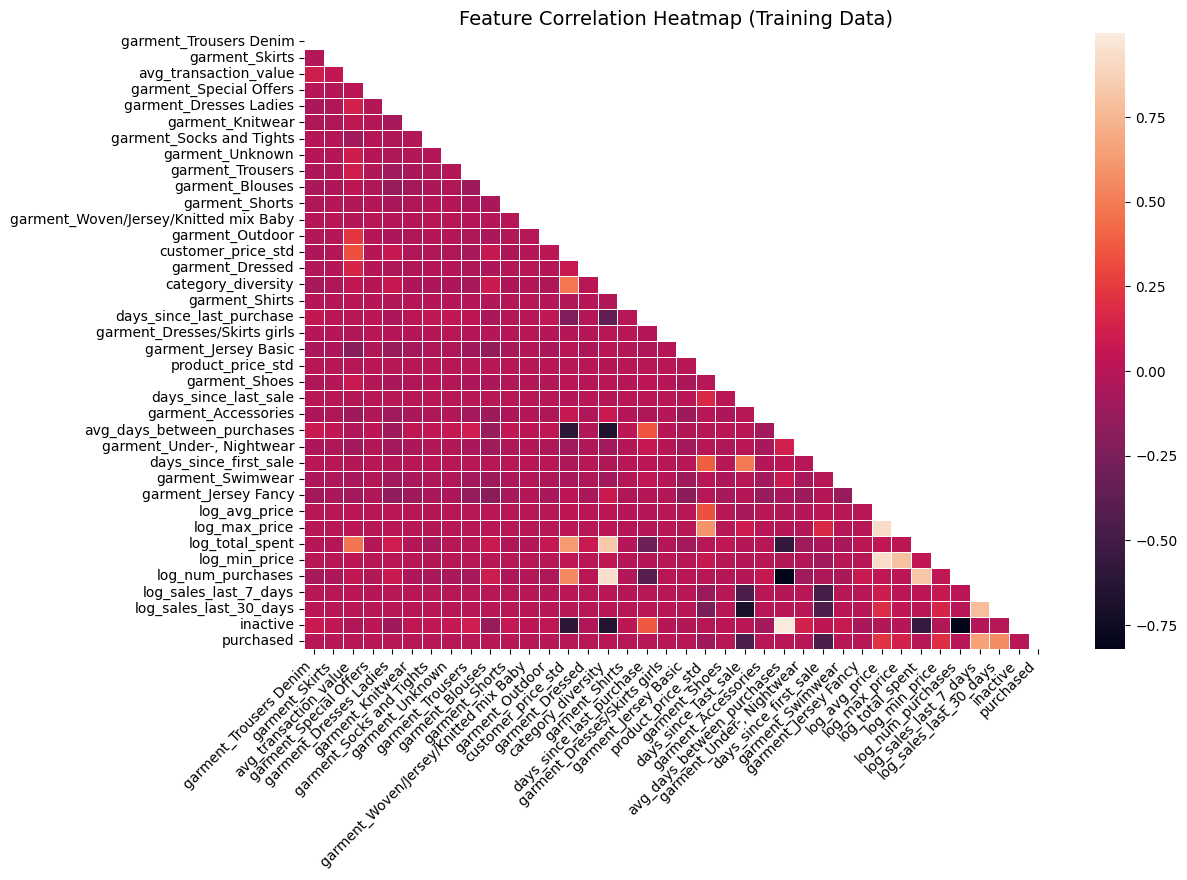

In [165]:
corr = pd.concat([X_train, y_train], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
ax = sns.heatmap(corr,mask=mask,annot=False, linewidths=.5)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Feature Correlation Heatmap (Training Data)', fontsize=14)
plt.show()

### Distribution of price

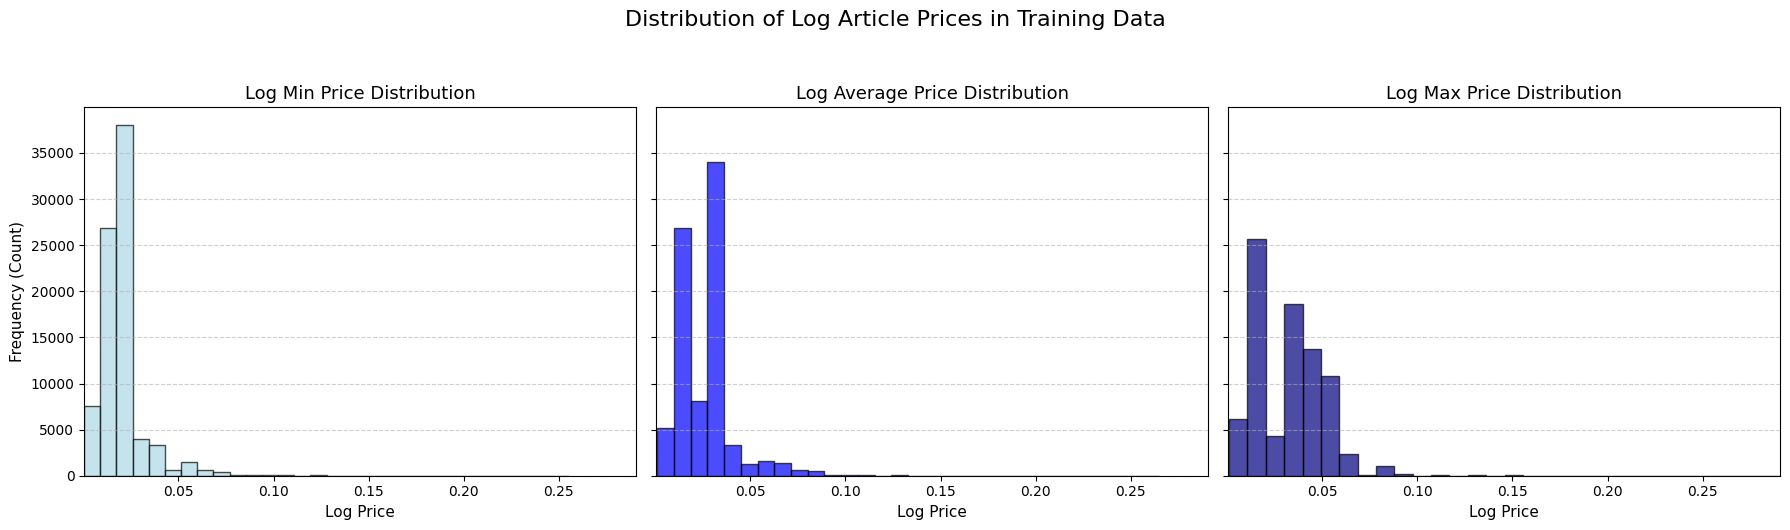

In [166]:
log_price_cols = ['log_min_price', 'log_avg_price', 'log_max_price']
X_train_prices = X_train[log_price_cols].copy()

x_min = X_train_prices.min().min()
x_max = X_train_prices.max().max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = ['Log Min Price Distribution', 'Log Average Price Distribution', 'Log Max Price Distribution']
colors = ['lightblue', 'blue', 'navy']

for i in range(3):
    axes[i].hist(X_train_prices[log_price_cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13)
    axes[i].set_xlabel("Log Price", fontsize=11)
    if i == 0:
        axes[i].set_ylabel("Frequency (Count)", fontsize=11)
    axes[i].set_xlim(x_min, x_max)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
fig.suptitle('Distribution of Log Article Prices in Training Data', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

### Customer Behavior Features

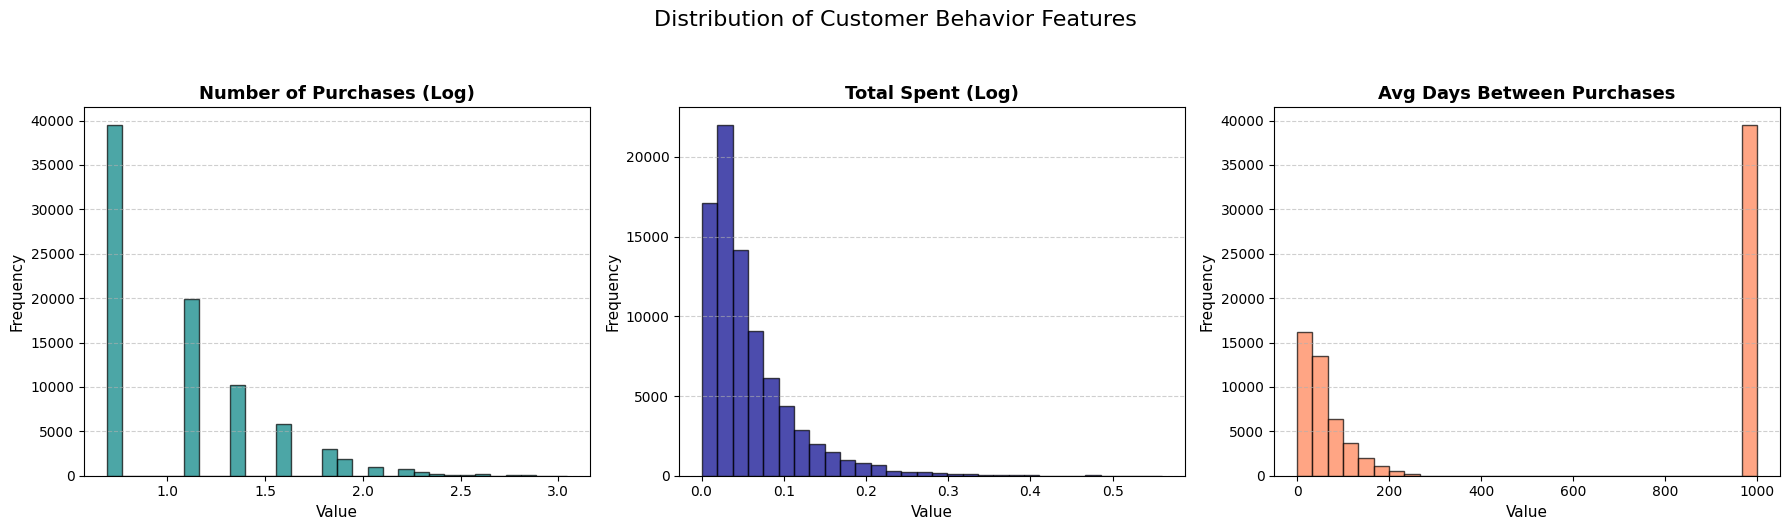

In [167]:
cols = ['log_num_purchases', 'log_total_spent', 'avg_days_between_purchases']
titles = ['Number of Purchases (Log)', 'Total Spent (Log)', 'Avg Days Between Purchases']
colors = ['teal', 'darkblue', 'coral']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    axes[i].hist(X_train[cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Distribution of Customer Behavior Features', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Sales over time

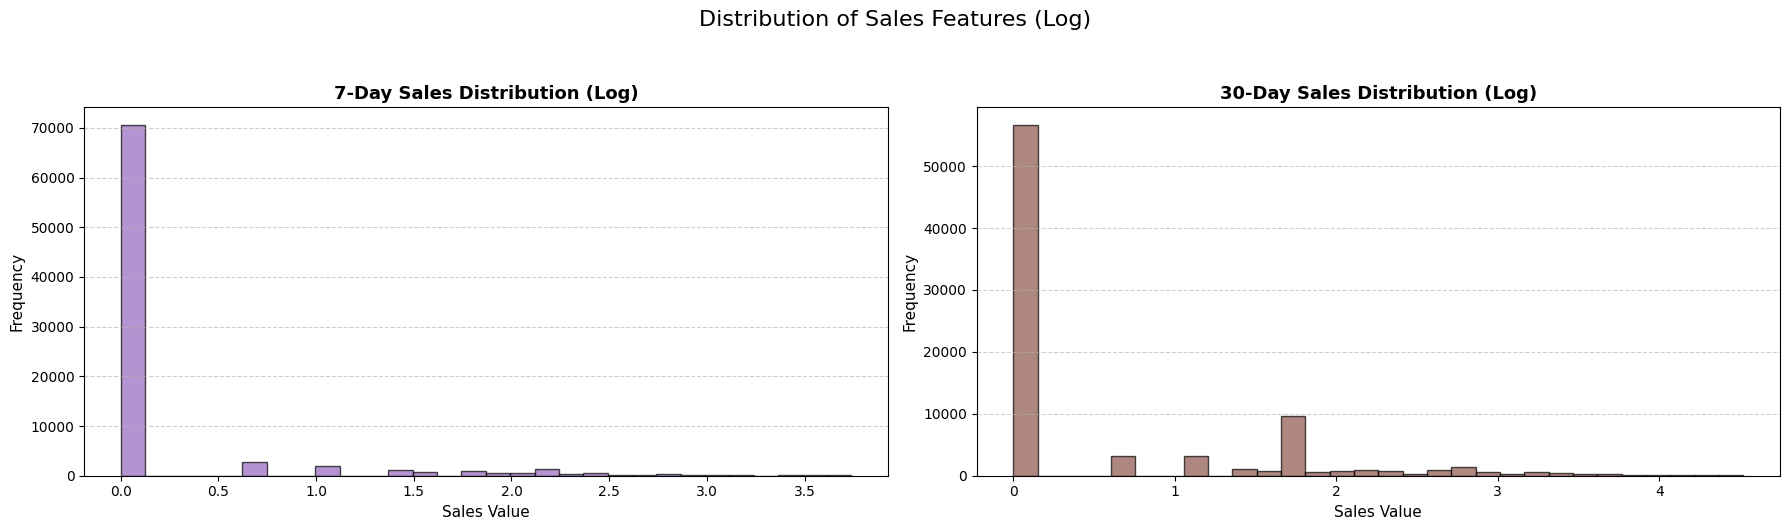

In [168]:
sales_cols = ['log_sales_last_7_days', 'log_sales_last_30_days']
titles = [ '7-Day Sales Distribution (Log)', '30-Day Sales Distribution (Log)']
colors = [ '#9467bd', '#8c564b']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for i in range(2):
    axes[i].hist(X_train[sales_cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Sales Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Distribution of Sales Features (Log)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## Model building

Build a neural net model with variable number of hidden layers.

- num_features: number of features in dataset
- hidden_layer_sizes: variable array of nodes in hidden layers of neural net
- learning_rate: hyperparameter learning rate
- activation: activation function used within hidden layers
- optimizer: Adam or SGD optimizer

Uses sigmoid activation for the final layer. Reports accuracy.

In [30]:
class MajorityClassifier:  
    def fit(self, X, y):
        y_actual = self._y_actual(y)
        
        self.majority = y_actual.mode()[0]
        self.majority_probability = (y_actual == self.majority).mean()
        self.class_probabilities = y_actual.value_counts(normalize=True).sort_index()
        self.classes = self.class_probabilities.index.to_list()

    def predict(self, X):
        return np.full(len(X), self.majority)

    def evaluate(self, X, y):
        prediction = self.predict(X)
        actual = self._y_actual(y)
        accuracy = (prediction == actual).mean()
        return {'accuracy': accuracy}

    def log_loss(self, y):
        y_actual = self._y_actual(y)
        
        predicted_probabilities = np.tile(self.class_probabilities.values, (len(y), 1))
        
        y_one_hot = np.zeros((len(y), len(self.classes)))
        for i, val in enumerate(y_actual):
            class_idx = self.classes.index(val)
            y_one_hot[i, class_idx] = 1 
        
        log_p = np.log(np.clip(predicted_probabilities, 1e-15, 1))
        return -np.sum(y_one_hot * log_p) / len(y)
    
    def _y_actual(self, y):
        return y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y

In [35]:
baseline = MajorityClassifier()
baseline.fit(X_train_scaled, y_train)

print(f"Baseline predictions: Always predict {baseline.majority}")
print(f"Training accuracy: {baseline.evaluate(X_train_scaled, y_train)['accuracy']:.4f}")
print(f"Training loss: {baseline.log_loss(y_train):.4f}")

print(f"Validation accuracy: {baseline.evaluate(X_val_scaled, y_val)['accuracy']:.4f}")
print(f"Validation loss: {baseline.log_loss(y_val):.4f}")

Baseline predictions: Always predict 0
Training accuracy: 0.8333
Training loss: 0.4506
Validation accuracy: 0.8333
Validation loss: 0.4506


In [14]:
def build_recommendation_model(num_features,
                                hidden_layer_sizes=[512],
                                learning_rate=0.001,
                                activation='relu',
                                optimizer="Adam"):
    tf.keras.backend.clear_session()
    tf.random.set_seed(67)

    model = tf.keras.Sequential()
    for i, layer_units in enumerate(hidden_layer_sizes):
        if i == 0:
            layer = tf.keras.layers.Dense(
                units=layer_units,
                input_shape=(num_features,),
                use_bias=True,
                activation=activation,
                kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
                bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
            )
        else:
            layer = tf.keras.layers.Dense(
                units=layer_units,
                use_bias=True,
                activation=activation,
                kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
                bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
            )
        model.add(layer)
    
    model.add(tf.keras.layers.Dense(
        units=1,
        use_bias=True,
        activation='sigmoid',
        kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
        bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
        )
    )

    if optimizer == "SGD":
        keras_optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "Adam":
        keras_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        keras_optimizer = optimizer

    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),
        optimizer=keras_optimizer,
        metrics=['accuracy']
    )
    
    return model

In [173]:
model = build_recommendation_model(X_train_scaled.shape[1],
                                    hidden_layer_sizes=[128],
                                    learning_rate=0.0001,
                                    activation='relu',
                                    optimizer="Adam")
model.summary()
history = model.fit(X_train_scaled, y_train,
                    validation_data=(X_val_scaled, y_val),
                    epochs=5,
                    batch_size=32,
                    verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8848 - loss: 0.3718 - val_accuracy: 0.9329 - val_loss: 0.2014
Epoch 2/5
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9178 - loss: 0.2497 - val_accuracy: 0.9275 - val_loss: 0.1918
Epoch 3/5
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9200 - loss: 0.2264 - val_accuracy: 0.9254 - val_loss: 0.1851
Epoch 4/5
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9215 - loss: 0.2161 - val_accuracy: 0.9242 - val_loss: 0.1865
Epoch 5/5
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9230 - loss: 0.2132 - val_accuracy: 0.9217 - val_loss: 0.1893


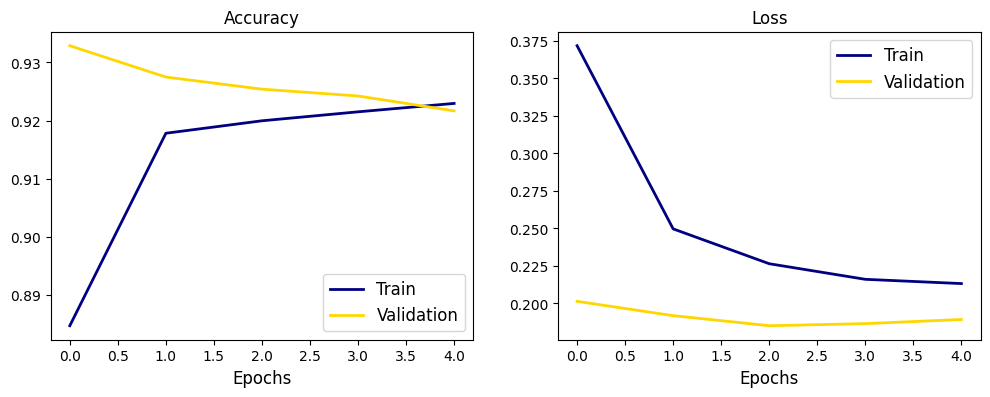

In [174]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history.history['accuracy'], lw=2, color='navy')
plt.plot(history.history['val_accuracy'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('Accuracy', size=12)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history.history['loss'], lw=2, color='navy')
plt.plot(history.history['val_loss'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('Loss', size=12)

plt.show()

## Test Data

In [175]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\n{'='*60}")
print(f"FINAL MODEL EVALUATION")
print(f"{'='*60}")
print(f"\nBaseline (Majority Class):")
print(f"  Accuracy: 83.33%  |  Loss: 0.4506")
print(f"\nNeural Network Results:")
print(f"  Train Accuracy:      {history.history['accuracy'][-1]*100:.2f}%")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"  Test Accuracy:       {test_acc*100:.2f}%")
print(f"  Test Loss:           {test_loss:.4f}")
print(f"\nImprovement over Baseline:")
print(f"  +{(test_acc - 0.8333)*100:.2f} percentage points")
print(f"  {((0.4506 - test_loss)/0.4506)*100:.1f}% reduction in loss")


FINAL MODEL EVALUATION

Baseline (Majority Class):
  Accuracy: 83.33%  |  Loss: 0.4506

Neural Network Results:
  Train Accuracy:      92.30%
  Validation Accuracy: 92.17%
  Test Accuracy:       94.07%
  Test Loss:           0.1582

Improvement over Baseline:
  +10.74 percentage points
  64.9% reduction in loss


## Confusion Matrix

2681/2681 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step


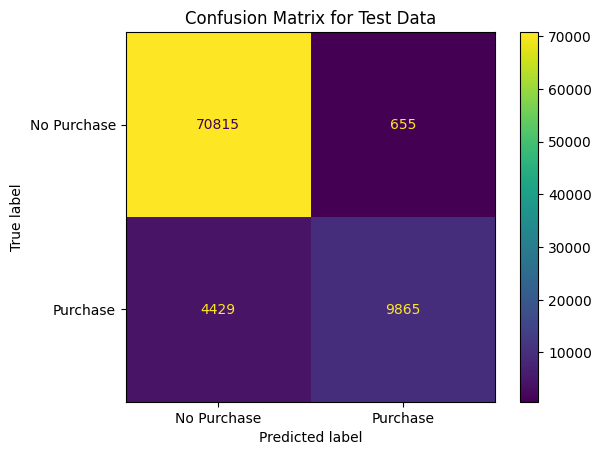

In [176]:
probability_threshold = 0.5

predictions = model.predict(x=X_test_scaled) > probability_threshold
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=LABELS)
disp.plot()
plt.title("Confusion Matrix for Test Data")
plt.show()

In [177]:
print("\nClassification Report:")
print(classification_report(y_test.values, predictions, target_names=LABELS))



Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.94      0.99      0.97     71470
    Purchase       0.94      0.69      0.80     14294

    accuracy                           0.94     85764
   macro avg       0.94      0.84      0.88     85764
weighted avg       0.94      0.94      0.94     85764



In [178]:
# Manual calculation for clarity
true_neg, false_pos, false_neg, true_pos = cm.ravel()
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)


print(f"  True Negatives:  {true_neg:,} (correctly predicted no purchase)")
print(f"  False Positives: {false_pos:,} (predicted purchase, but didn't buy)")
print(f"  False Negatives: {false_neg:,} (predicted no purchase, but did buy)")
print(f"  True Positives:  {true_pos:,} (correctly predicted purchase)")
print(f"\n")
print(f"  Precision: {precision:.2%} (of {(true_pos + false_pos):,} predicted purchases, how many were correct)")
print(f"  Recall:    {recall:.2%} (of {(true_pos + false_neg):,} actual purchases, how many did we catch)")

  True Negatives:  70,815 (correctly predicted no purchase)
  False Positives: 655 (predicted purchase, but didn't buy)
  False Negatives: 4,429 (predicted no purchase, but did buy)
  True Positives:  9,865 (correctly predicted purchase)


  Precision: 93.77% (of 10,520 predicted purchases, how many were correct)
  Recall:    69.01% (of 14,294 actual purchases, how many did we catch)
